In [1]:
from fiat_toolbox.well_being import (
    CapitalStock,
    CommunityUnit,
    IncomeConfig,
    Liquidity,
    SimulationConfig,
    WellBeingConfig,
)

In [2]:
housing_assets = CapitalStock(v=0.7, k=120000, pi=0.15)
rental_assets = CapitalStock(v=0.7, k=80000, recovery_time=10, pi=0.15)

public_assets = CapitalStock(v=0.4, k=1e-2 * 5000000, recovery_time=10, pi=0.15)
private_assets = CapitalStock(v=0.4, k=1e-2 * 5000000, recovery_time=4, pi=0.15)

# Baseline c0 = Σ π·k + i_div = 0.15*(120000+80000+50000+50000) + 20000 = 65000.
# i_div captures income not tied to any modelled stock (transfers, etc.).
income_config = IncomeConfig(i_avg=48000, i_div=20000)

sim_config = SimulationConfig(
    eta=1.5, rho=0.06, t_max=10, dt=1 / 52, currency="$", c_min=5000, recovery_per=95.0
)

liq = Liquidity(savings=0)

config = WellBeingConfig(
    owner_housing=housing_assets,
    labour_assets={"Public": public_assets, "Private": private_assets},
    rental_housing=rental_assets,
    income=income_config,
    simulation=sim_config,
    liquidity=liq,
)

In [3]:
# Create a WellBeing object and optimize the lambda value
household = CommunityUnit(config=config)
household

CommunityUnit(
  owner_housing = k=120000.0 v=0.7 recovery_time=None recovery_rate=None pi=0.15 recovery_label=None income_label=None,
  rental_housing = k=80000.0 v=0.7 recovery_time=10.0 recovery_rate=0.299573227355399 pi=0.15 recovery_label=None income_label=None,
  labour_assets = {'Public': CapitalStock(k=50000.0, v=0.4, recovery_time=10.0, recovery_rate=0.299573227355399, pi=0.15, recovery_label=None, income_label=None), 'Private': CapitalStock(k=50000.0, v=0.4, recovery_time=4.0, recovery_rate=0.7489330683884975, pi=0.15, recovery_label=None, income_label=None)},
  income = i_0=None i_avg=48000.0 i_div=20000.0,
  liquidity = savings=0.0 insurance=0.0 support=0.0,
  simulation = eta=1.5 rho=0.06 t_max=10.0 dt=0.019230769230769232 currency='$' c_min=5000.0 recovery_per=95.0
)

Status: boundary_lower
Success: True
Message: Minimum at lower λ bound (0.3 ≈ l_min), i.e. the slowest recovery / longest reconstruction time in the search range. Welfare may keep improving beyond this bound. Hint: widen the search (increase rec_time_max on CommunityUnit.opt_lambda).


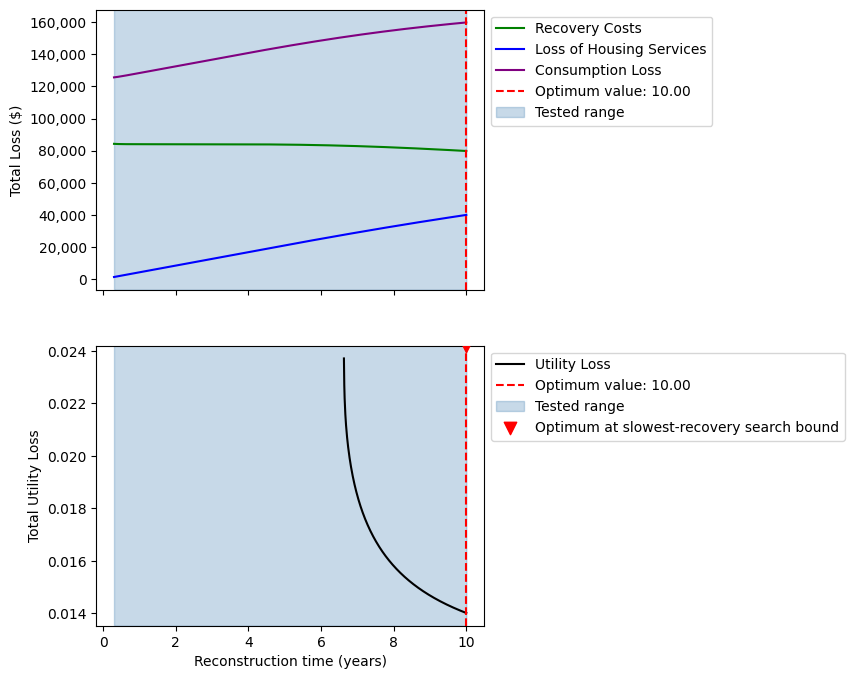

In [4]:
res = household.opt_lambda(raise_on_fail=False)
# opt_lambda classifies its outcome via `res["status"]` (OptLambdaStatus):
# INTERIOR / FLAT / BOUNDARY_LOWER / BOUNDARY_UPPER / INFEASIBLE / FAILED.
# `res["message"]` carries a short explanation and an actionable hint
# whenever the result is non-trivial. For this config the optimum lands at
# the slowest end of the λ search range (BOUNDARY_LOWER) — the plot
# annotates the boundary with a red marker.
print(f"Status: {res['status']}")
print(f"Success: {res['success']}")
if res["message"]:
    print(f"Message: {res['message']}")
if res["success"]:
    household.plot_opt_lambda(x_type="time")

In [5]:
household.get_losses("trapezoid")

Recovery Costs                        79800.219863
Loss of Housing Services              39956.951711
Loss of Housing Services (Rental)     26637.967808
Labour Income Loss (Public)            9513.559931
Labour Income Loss (Private)           4003.528094
Labour Income Loss                    13517.088025
Consumption Loss                     159912.227407
Utility Loss                              0.014013
Wellbeing Loss                       147365.423784
Wellbeing Loss (Integral)            147365.423784
Wellbeing Loss (Liquidity Term)           0.000000
Asset Loss                            84000.000000
Equity Weighted Asset Loss            53305.387793
Socio-economic Resilience                 0.570012
dtype: float64

In [6]:
print(f"Recovery Time: {household.recovery_time:.2f} years")
print(
    f"Achieved recovery in {household.config.simulation.t_max} years: {household.achieved_recovery_percent():.2f} %"
)

Recovery Time: 10.00 years
Achieved recovery in 10.0 years: 95.55 %


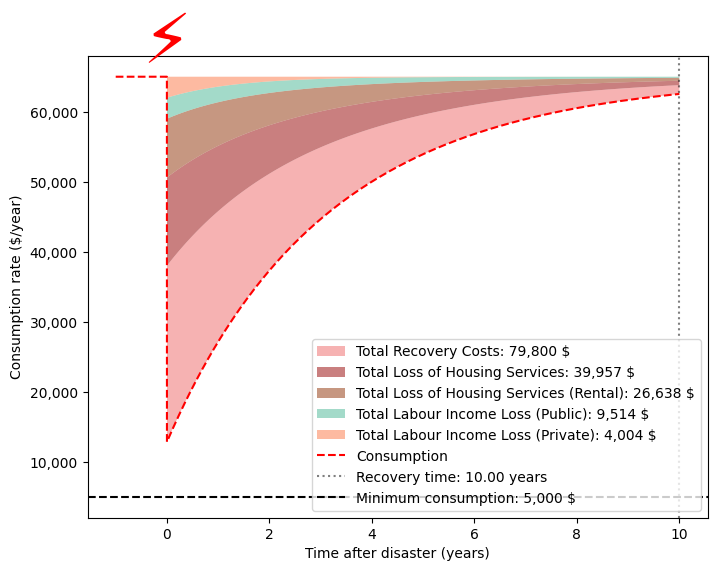

In [7]:
household.plot_consumption()